In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [2]:
df = pd.read_csv("./RegData.csv")
df.sample(5)

,StID,SAT,GPA
37,145,1261,3.19
59,171,1164,2.52
24,127,1393,3.50
14,115,1275,3.29
52,164,1308,3.32


In [3]:
col2 = df["GPA"]

In [4]:
import warnings
warnings.filterwarnings("ignore")
def dist2Cart(c2):
    plt.figure(figsize=(16, 5))
    plt.subplot(1, 2, 2)
    sns.distplot(c2)
    plt.show()

In [5]:
def dist2Chart(c2):
    plt.figure(figsize=(16, 5))
    plt.subplot(1, 2, 2)
    sns.histplot(c2)
    plt.show()

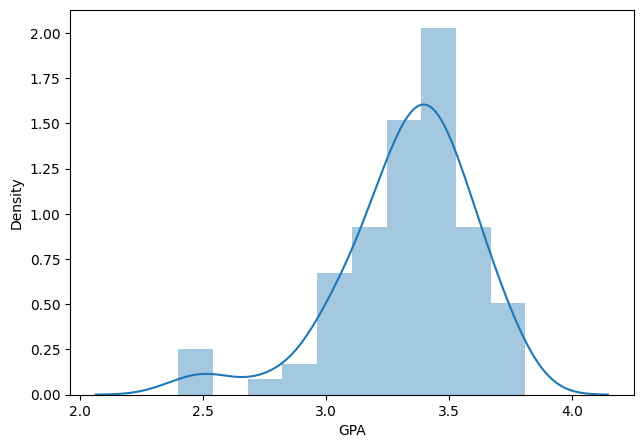

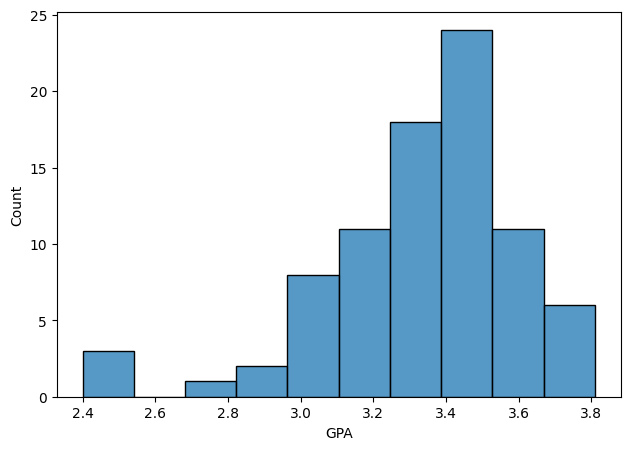

In [6]:
dist2Cart(col2)
dist2Chart(col2)

<Axes: ylabel='GPA'>

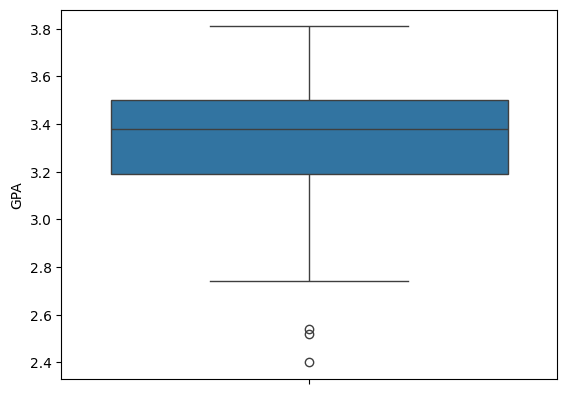

In [7]:
sns.boxplot(col2)

In [8]:
q1 = col2.quantile(0.25)
q2 = col2.quantile(0.50)
q3 = col2.quantile(0.75)
print("Min = 0.0")
print("percentile 25% = ", q1)
print("percentile 50% = ", q2)
print("percentile 75% = ", q3)
print("Max = 100.0")

Min = 0.0
percentile 25% =  3.19
percentile 50% =  3.38
percentile 75% =  3.5025
Max = 100.0


In [9]:
iqr = q3 - q1
float(iqr)

0.3125

In [10]:
iqrVal = 1.5 * iqr
lower_limit = q1 - iqrVal
upper_limit = q3 + iqrVal
print("Lower limit: ", lower_limit)
print("Upper Limit: ", upper_limit)

Lower limit:  2.72125
Upper Limit:  3.97125


In [11]:
df[col2 < lower_limit].count()

StID    3
SAT     3
GPA     3
dtype: int64

In [12]:
df[col2 > upper_limit].count()

StID    0
SAT     0
GPA     0
dtype: int64

In [13]:
df[col2 > upper_limit]

,StID,SAT,GPA


In [14]:
new_df = df[(col2 > lower_limit) & (col2 < upper_limit)]
new_df.shape

(81, 3)

### Trimming of Outliers

<Axes: ylabel='GPA'>

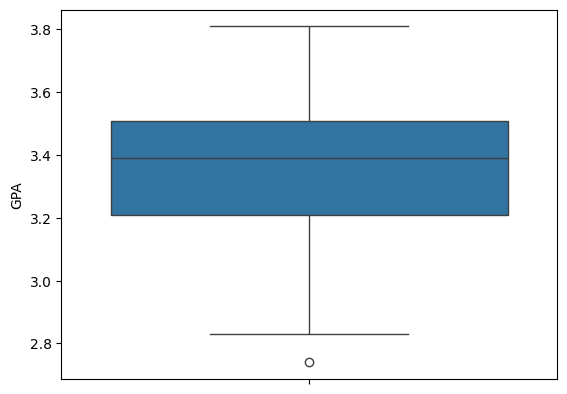

In [15]:
sns.boxplot(new_df["GPA"])

In [16]:
new_df.to_csv("./RegData_new.csv")

### Comparing

<Axes: ylabel='GPA'>

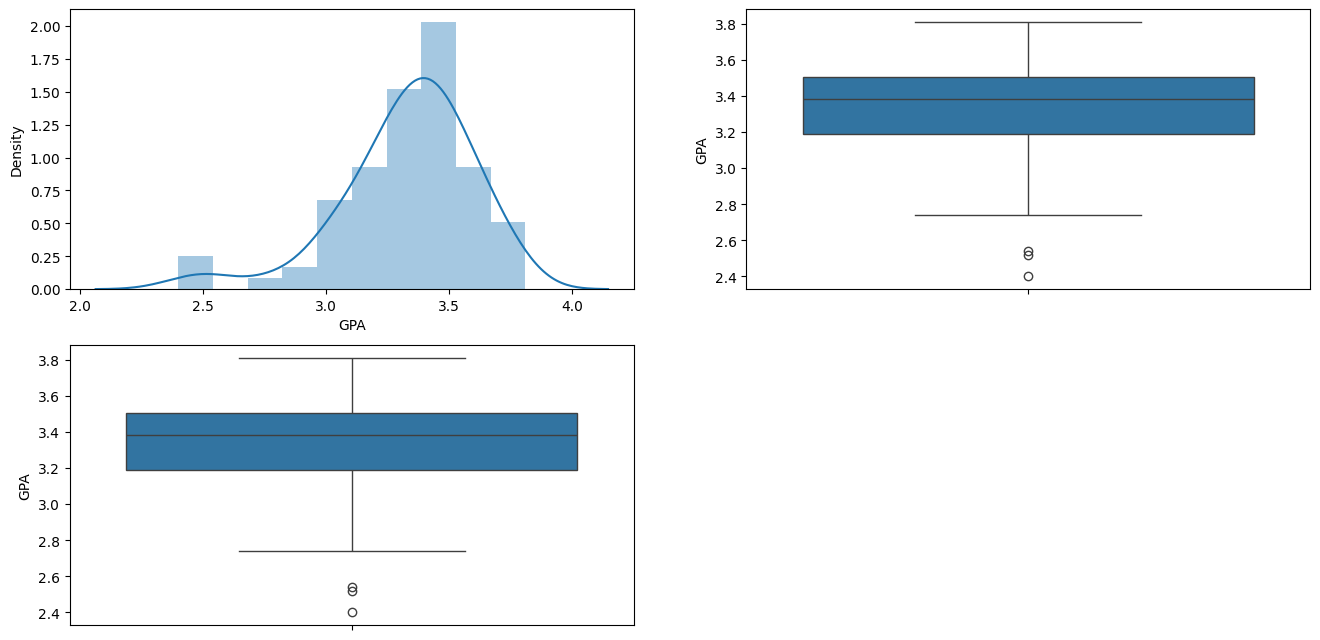

In [17]:
plt.figure(figsize=(16, 8))
plt.subplot(2, 2, 1)
sns.distplot(df.GPA)

plt.subplot(2, 2, 2)
sns.boxplot(df.GPA)

plt.subplot(2, 2, 3)
sns.boxplot(df.GPA)